[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UTILISATEUR/PROJET/blob/main/votre_notebook.ipynb)


# Unconditional generation

The goal of this notebook is to implement the backward procedure of the diffusion generative model.

## Recall: Forward process

The forward process is the Markov Chain defined as

$$X_{t+1} = X_{t} + \sigma_t Z_t\;,$$

with $X_0 \sim p_{0}$ and $Z_t$ iid Standard gaussian distributions.


## Recall: Backward process

The backward process is the Markov chain that best approximates the joint law of the forward process, which is characterized by the two moments $\mathbb{E}[X_t | X_{t+1}=x]$ and $\mathbb{V}[X_t | X_{t+1}=x]$. We consider that we have a denoiser network $D_{\theta}$ that approximates $\mathbb{E}[X_t | X_{t+1}=x]$. 

In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Callable
from tqdm import tqdm
import math

In [2]:
def ddpm(
    sigmas: torch.Tensor,
    initial_samples: torch.Tensor,
    denoiser_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
) -> torch.Tensor:
    # Implement your code here!
    samples = initial_samples
    for sigma_tm1, sigma_t in tqdm(zip(reversed(sigmas[:-1]), reversed(sigmas[1:]))):
        denoised_x0 = denoiser_fn(samples, sigma_t)
        mean = denoised_x0 + ((sigma_tm1/sigma_t)**2) * (samples - denoised_x0)
        std = (((sigma_tm1/sigma_t)**2) * (sigma_t**2 - sigma_tm1**2))**.5
        samples = mean + std * torch.randn_like(mean)
    return samples
    

## First example: Mixture of Gaussians

We are first going to use a Mixture of Gaussians as the target distribution. This is particularly interesting from the visualization point of view and also because we have the "true score" function.


/home/ndesassis/workshopDD/diffusion/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_49004/3821725991.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


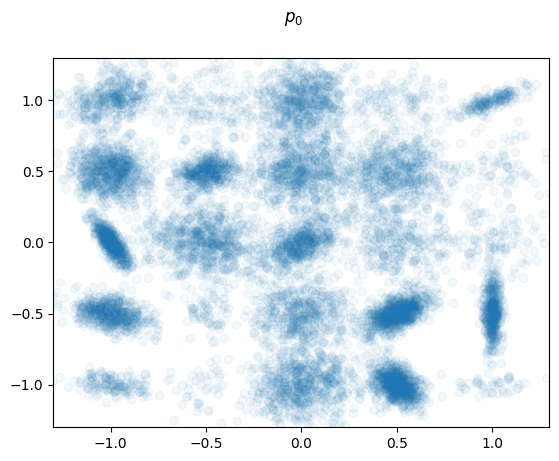

In [3]:
def get_random_unitary(n=20, dim=2):
    seeds = torch.randn((n, dim, dim))
    U, _, _ = torch.linalg.svd(seeds)
    S = torch.stack([torch.diag(s) for s in torch.rand((n, dim))])
    return U @ S @ U.mT

means = torch.stack(
    torch.meshgrid(
        torch.linspace(-1, 1, 5),
        torch.linspace(-1, 1, 5),
    )
).flatten(1, 2).T
covars = get_random_unitary(n=means.shape[0], dim=means.shape[1])*(0.15**2)
weights = torch.rand(means.shape[0])
weights = weights / weights.sum()
def make_noised_mixture(means, covars, weights, sigma):
    return torch.distributions.MixtureSameFamily(
        component_distribution=torch.distributions.MultivariateNormal(
            loc=means, covariance_matrix=covars + torch.eye(covars.shape[-1])[None]*sigma**2
        ),
        mixture_distribution=torch.distributions.Categorical(probs=weights)
    )

def denoiser_fn_mixture(x, sigma):
    score = torch.func.grad(lambda y: make_noised_mixture(means, covars, weights, sigma).log_prob(y).sum())(x)
    return x + (sigma**2) * score

fig, ax = plt.subplots(1, 1)
fig.suptitle(r"$p_{0}$")
ax.scatter(*make_noised_mixture(means, covars, weights, sigma=0).sample((10_000,)).T, alpha=.05)
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
fig.show()

999it [00:05, 186.41it/s]
/tmp/ipykernel_49004/1610342327.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


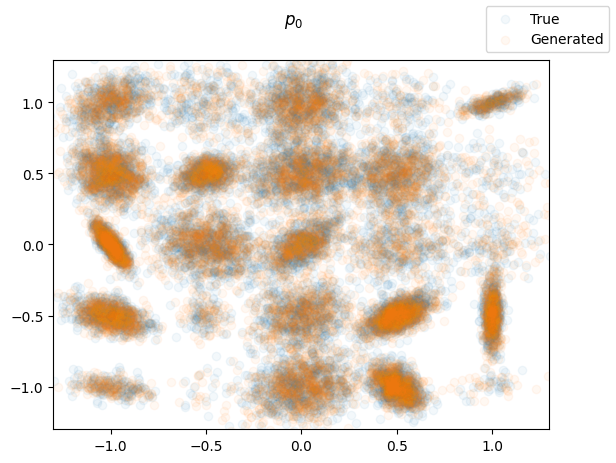

In [4]:
sigmas = torch.linspace(0.002**(1/3), 80**(1/3), 1000)**3
generated_samples = ddpm(
    initial_samples = torch.randn((10_000, 2))*((sigmas[-1]**2 + 1)**.5),
    sigmas = sigmas,
    denoiser_fn=denoiser_fn_mixture
)
fig, ax = plt.subplots(1, 1)
fig.suptitle(r"$p_{0}$")
ax.scatter(*make_noised_mixture(means, covars, weights, sigma=0).sample((10_000,)).T, alpha=.05, label="True")
ax.scatter(*generated_samples.T, alpha=.05, label="Generated")
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
fig.legend()
fig.show()

In [5]:
from diffusers import UNet2DModel, DDPMScheduler

model_id = "google/ddpm-celebahq-256"
scheduler = DDPMScheduler.from_pretrained(model_id)
model = UNet2DModel.from_pretrained(model_id).to("cuda").eval().requires_grad_(False)


def denoiser_fn_hf(x, sigma):
    # This part belows convert the variance exploding framework to the variance preserving.

    eq_alpha = 1 / (sigma**2 + 1)
    get_closest = torch.abs(scheduler.alphas_cumprod - eq_alpha).argmin().item()
    closest_alpha = scheduler.alphas_cumprod[get_closest]
    eq_x = x / (sigma**2 + 1)**.5
    
    out_model = model(eq_x, get_closest).sample
    pred_x0 = ((eq_x  -  ((1 - closest_alpha)**.5)*out_model) / (closest_alpha**.5)).clip(-1, 1)
    return pred_x0

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [6]:
sigmas = (1/scheduler.alphas_cumprod - 1)**.5
generated_samples = ddpm(
    initial_samples = torch.randn((1, 3, 256, 256), device="cuda")*((sigmas[-1]**2 + 1)**.5),
    sigmas = sigmas,
    denoiser_fn=denoiser_fn_hf
)

999it [08:28,  1.97it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.017548025..1.0014954].
/tmp/ipykernel_49004/566049464.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


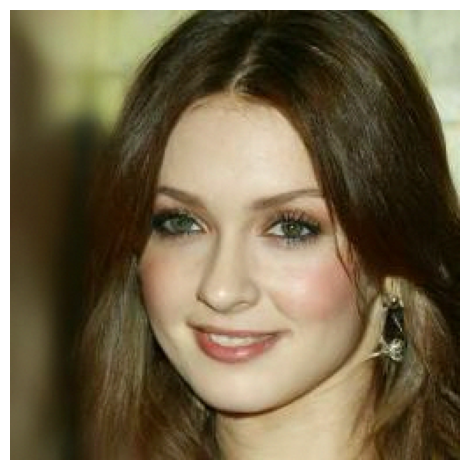

In [7]:
fig, ax = plt.subplots(1, 1)
ax.imshow(((generated_samples[0] + 1)/2).permute(1, 2, 0).cpu())
ax.set_axis_off()
fig.tight_layout()
fig.show()